In [15]:
import numpy as np
import logging
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('TkAgg')
%matplotlib inline
logging.getLogger().setLevel(logging.ERROR)
np.random.seed(100)

<h1 style="text-align:center;">Numerical Methods for <br>Stochastic Differential Equations<br></h1>
<br>
<div style="text-align:center;"><b>Abstract</b></div>
<div style="text-align:center;">
We examine numerical methods to simulate stochastic differential equations.
</div>
<br>
<div style="text-align:center;">
<b>Keywords</b> -- Mathematics, Ito Calculus, Stochastic Calculus, Numerical Methods, Timeseries simulations
</div>

<h2 style="text-align:center;">MOTIVATION</h2>

**Stochastic differential equations** (SDE) in most practical settings cannot be solved analytically. In such cases, we turn to numerical methods in order to simulate a solution. We review the analytical solutions and then apply the numerical methods.

<h2 style="text-align:center;">Ordinary Differential Equations</h2>

In ordinary calculus, we usually want to find values of a function given the rate of change. For example, let $f(t)$ denote the position of a particle at time $t$ and that we are given the function for the rate of change as

\begin{align}
df(t)=C\big(t, f(t) \big) dt
\end{align}

Then given the initial condition $f(0)=x_0$, we can approximate the function for some small increment of $t$ using the **Euler's** method:

\begin{align}
f(t + \Delta t) = f(t) + C\big(t, f(t)\big) \Delta t
\end{align}

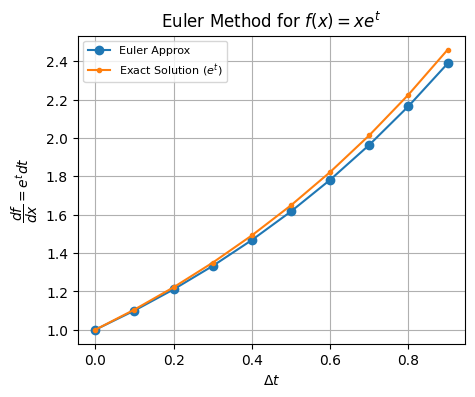

In [16]:
## Compare analytical solution to Euler approximation on ODE
# f(x)  = xe^t
# df/dx = e^tdt
def dfdx(t):
    return np.exp(t)

# Parameters
N = 10                # Number of increments
T = 1                 # Time horizon
dt = T/N              # Step size
t = np.arange(0,1,dt) # timesteps
y0 = 1

# Euler approximation
y = np.zeros(N)
y[0] = y0
for i in range(1, N):
    y[i] = y[i-1] + dfdx(t[i-1])*dt

# Exact Solution for comparison: df/dx = e^tdt
y_exp = np.exp(t)

plt.figure(figsize=(5, 4))
plt.plot(t, y, marker="o", label='Euler Approx')
plt.plot(t, y_exp, marker=".", label='Exact Solution ($e^t$)')
plt.title('Euler Method for $f(x)=xe^t$',size=12)
plt.xlabel('$\Delta t$')
plt.ylabel('$\dfrac{df}{dx}=e^tdt$')
plt.legend(prop={"size":8})
plt.grid(":")
plt.show()

**Euler's method** is a simple way to approximate ordinary differential equation. By taking smaller step sizes for $\Delta t$ we reach closer and closer approximations to the exact value of the function. On the other hand, the method to approximate a stochastic differential equation is using **Euler-Maruyama method**.

<h2 style="text-align:center;">Stochastic Differential Equation</h2>

**Euler-Maruyama** method is derived by approximating the integral form of the stochastic differential equation over an infinitesimal time interval $[t_n,t_{n+1}]$. It is the **stochastic** analogue of the standard **Euler** method for ordinary differential equation.

Consider the stochastic process $X(t)$ that satisfies the **Ito** differential equation

\begin{align}
dX_t = f(X_t)dt + g(X_t)dW_t \quad\quad (1)
\end{align}

where $f$ is the **drift** coefficient and $g$ is the **diffusion** coefficient, moreover $W_t$ is a **Brownian** process

**Express** the given differential equation in integral for over a a single time step $\Delta t= t_{n+1} - t_n$,

\begin{align}
X_{t_{n+1}} = X_{t_n} + \int_{t_n}^{t_{n+1}} f(X_s)ds + \int_{t_n}^{t_{n+1}} g(X_s)dW_s
\end{align}

**Discretize** the integral equation, assume the coefficients $f(X_s)$ and $g(X_s)$ are constants over the interval $[t_n, t_{n+1}]$. Evaluate the integral from the left endpoint.

\begin{align}
f(X_s) \approx f(X_{t_n})\\
g(X_s) \approx g(X_{t_n})
\end{align}

Substitute to the integral equation

\begin{align}
X_{t_n+1} =  X_{t_n} + f(X_{t_n}) \int_{t_n}^{t_{n+1}} ds + g(X_{t_n}) \int_{t_n}^{t_{n+1}} dW_s
\end{align}

**Evaluate** the deterministic integral $\int_{t_n}^{t_{n+1}} ds$ which simply evaluates to $\Delta t$. The stochastic integral $\int_{t_n}^{t_{n+1}} dW_s$, represents the increment of the Wiener processs denoted as $\Delta W_n = W_{t_{n+1}} - W_{t_n}$

**Substitute** the evaluated terms to (1)

\begin{align}
X_{t_{n+1}} =  X_{n} + f(X_n) \Delta_t + g(X_n) \Delta W_n
\end{align}

In practical simulations, $\Delta W_n$ is drawn from a normal distribution with mean $0$ and variance $\Delta t$, often implemented as $\sqrt{\Delta t}\cdot \mathcal{N}(0,1)$

Therefore the approximation using **Euler-Maruyama method** is derived as

\begin{align}
X_{t_{n+1}} =  X_{n} + f(X_n) \Delta_t + g(X_n) \Delta W_n
\end{align}

This formula provides approximation for the depth of the path of the stochastic process by treating drift and diffusion as constants over each distrete timestep.

On the other hand, we compute the actual price $S_t$ as a geometric **Brownian** process that changes by a random factor over a time interval $\Delta t$.

\begin{align}
\Delta S = S(t+\Delta t) - S(t)
\end{align}

From the differential form

\begin{align}
dS = \mu Sdt + \sigma S dW_t
\end{align}

We use $S(t+\Delta t)$ below which is solved using **Ito's lemma**

\begin{align}
S_{t+1} = S_t \exp \left[\left(\mu - \frac{1}{2}\sigma^2\right) t + \sigma W_t \right]
\end{align}


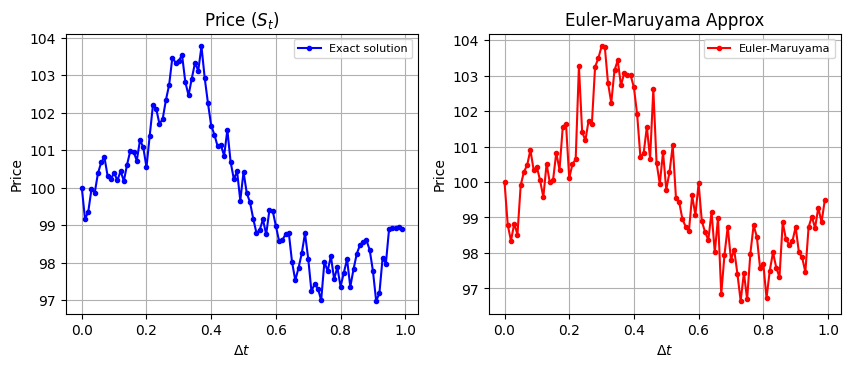

In [17]:
mu = 0.03    # Drift
sigma = 0.05 # Diffusion
N = 100      # Number of time steps
T = 1        # Time horizon
dt = T/N     # step size
s0 = 100     # Start value 
t = np.arange(0, T, dt) # Time steps

# Geometric Brownian Price
S = np.zeros(N)
S[0] = s0
for i in range(1, N):
    W = np.random.normal(0,1,size=1)
    diff = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*W
    S[i] = S[i-1] * np.exp(diff)
    
# Euler-Maruyama Approx
S_hat = np.zeros(N)
S_hat[0] = s0
for i in range(1, N):
    W = np.random.normal(0, 1, size=1)
    S_hat[i] = S[i-1] + mu*S_hat[i-1] * dt + sigma*S_hat[i-1]*np.sqrt(dt)*W
    
fig = plt.figure(figsize=(10,8))
ax0 = fig.add_subplot(221)
ax0.plot(t, S, label="Exact solution", color="b", marker=".")
ax0.set_xlabel("$\Delta t$")
ax0.set_ylabel(r"Price")
ax0.legend(prop={"size":8})
ax0.set_title(r"Price ($S_t$)")
ax0.grid(":")

ax1 = fig.add_subplot(222)
ax1.plot(t, S_hat, label="Euler-Maruyama",color="r", marker=".")
ax1.set_xlabel("$\Delta t$")
ax1.set_ylabel("Price")
ax1.legend(prop={"size":8})
ax1.set_title(r"Euler-Maruyama Approx")
ax1.grid(":")
plt.show()

<h2 style="text-align:center;">Convergence of Approximation</h2>

**Definition**. Let $X(t)$ be a process and $X_n$ denote the approximation of the value of $X(T)$ where $T = n\Delta t$. The **weak error** $e_{\Delta t}^{\text{weak}}$ with respect to some function $f$ is defined as:

\begin{align}
e_{\Delta t}^{\text{weak}} = \sup_{0 \lt t_n \le T} \bigg|\mathbb{E}\big[f(X_n)\big] - \mathbb{E}\big[f(X(t_n))\big] \bigg|
\end{align}

We say that $X_n$ converges weakly to $X(t)$ with order $\rho \gt 0$ if there exists a constant $C \gt 0$ independent of  $\Delta t$ such that:

\begin{align}
e_{\Delta t}^{\text{weak}} \le C \Delta t^{\rho}
\end{align}

for all sufficiently small $\Delta t$.

**Definition**. We define the **strong error** as $e_{\Delta t}^{\text{strong}}$ as:

\begin{align}
e_{\Delta t}^{\text{strong}} = \sup_{0 \le t_n \le T} \mathbb{E}\left[\left|X_n - X_{t_n}\right|\right]
\end{align}

We can say $X_n$ converges strongly to $X_t$ with the order $\rho \gt 0$ if there exists as constant $C \gt 0$ independent of $\Delta t$ such that

\begin{align}
e_{\Delta t}^{\text{strong}} \lt C \Delta t^{\rho}
\end{align}

for all sufficiently small $\Delta t$.

We can view weak convergence as the decay in the rate of the "error of the means" while strong convergence is the decay in the rate of the "mean of the errors". Strong convergence implies weak convergence, but the opposite is not necessarily true.

If a numerical scheme converges with the order $\rho$, then by decreasing the step size by a factor of $k$ reduces the error by a factor of $k^{\rho}$. For example, the order of $\rho=1$ means that decreasing the step size by a factor of $100$ also decreases the error by a factor of $100$. Meanwhile, an order of $\rho=\frac{1}{2}$ means that decreasing the step size by a factor of $100$ decreases the error by a factor of $10$.

**Euler-Maruyama method** converges strongly with the order $\rho=\frac{1}{2}$ or $O(\sqrt{\Delta t})$. This means the error decreases proportional to the square root of the step size, assuming the coefficients of the SDE satisfy Lipschitz continuity condition.

In [18]:
mu = 0.03    # Drift
sigma = 0.05 # Diffusion
M = 100      # Number of path evolution
T = 1        # Time horizon
s0 = 100     # Initial price

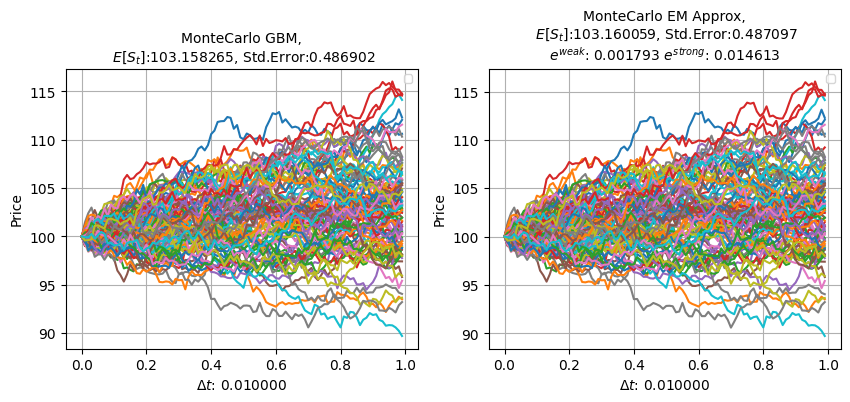

In [19]:
# Step size 0.01
N = 100                 # Number of time steps
dt = T/N                # step size
t = np.arange(0, T, dt) # Time steps
S_h = np.zeros((M,N))   # Approximation values
S_e = np.zeros((M,N))   # Expected values

for m in range(M):
    S_h[m, 0] = s0
    S_e[m, 0] = s0
    for n in range(1, N):
        W = np.random.normal(0, 1, size=1)
        S_h[m,n] = S_h[m, n-1] + mu*S_h[m, n-1] * dt + sigma*S_h[m,n-1]*np.sqrt(dt)*W
        diff = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*W
        S_e[m,n] = S_e[m, n-1] * np.exp(diff)
        
term_values = S_h[:, -1]
mean_value = np.mean(term_values)
std_error = np.std(term_values)/np.sqrt(M)
weak_error = np.abs(np.mean(S_e[:,-1]) - np.mean(S_h[:,-1]))
strong_error = np.mean(np.abs(S_e[:,-1] - S_h[:,-1]))

fig = plt.figure(figsize=(10,8))
ax0 = fig.add_subplot(221)
for m in range(0, M):
    ax0.plot(t, S_h[m,:])
ax0.set_xlabel("$\Delta t$: {:.6f}".format(dt))
ax0.set_ylabel("Price")
ax0.legend(prop={"size":8})
ax0.set_title("MonteCarlo GBM,\n $E[S_t]$:" 
             + "{:.6f}, Std.Error:{:.6f}".format(
                 mean_value, std_error), size=10)
ax0.grid(":")

term_values = S_e[:, -1]
mean_value = np.mean(term_values)
std_error = np.std(term_values)/np.sqrt(M)

ax1 = fig.add_subplot(222)
for m in range(0, M):
    ax1.plot(t, S_e[m,:])
ax1.set_xlabel("$\Delta t$: {:.6f}".format(dt))
ax1.set_ylabel("Price")
ax1.legend(prop={"size":8})
ax1.set_title("MonteCarlo EM Approx,\n $E[S_t]$:" 
            + "{:.6f}, Std.Error:{:.6f}\n".format(mean_value, std_error) 
            + r"$e^{weak}$: " + "{:.6f}".format(weak_error)
            + r" $e^{strong}$: " + "{:.6f}".format(strong_error), size=10)
ax1.grid(":")
plt.show()

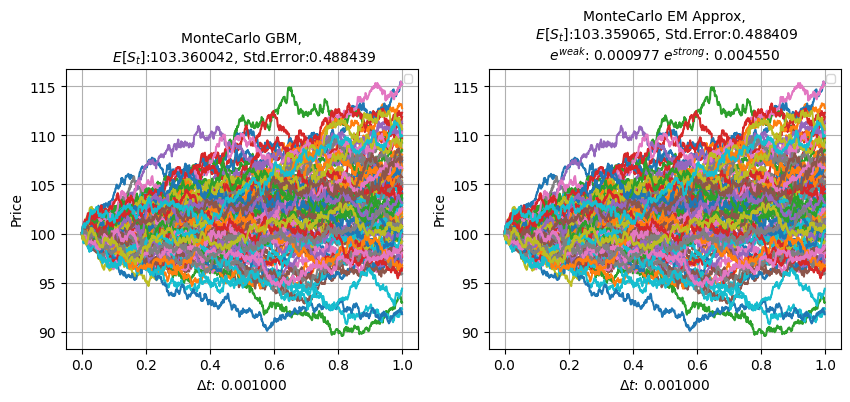

In [20]:
# Step size 0.001
N = 1000      # Number of time steps
T = 1        # Time horizon
dt = T/N     # step size
t = np.arange(0, T, dt) # Time steps
S_h = np.zeros((M,N))
S_e = np.zeros((M,N))

for m in range(M):
    S_h[m, 0] = s0
    S_e[m, 0] = s0
    for n in range(1, N):
        W = np.random.normal(0, 1, size=1)
        S_h[m,n] = S_h[m, n-1] + mu*S_h[m, n-1] * dt + sigma*S_h[m,n-1]*np.sqrt(dt)*W
        diff = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*W
        S_e[m,n] = S_e[m, n-1] * np.exp(diff)        

# Calculate and plot EM Approximated values.
term_values = S_h[:, -1]
mean_value = np.mean(term_values)
std_error = np.std(term_values)/np.sqrt(M)
weak_error = np.abs(np.mean(S_e[:,-1]) - np.mean(S_h[:,-1]))
strong_error = np.mean(np.abs(S_e[:,-1] - S_h[:,-1]))

fig = plt.figure(figsize=(10,8))
ax0 = fig.add_subplot(221)
for m in range(0, M):
    ax0.plot(t, S_h[m,:])
ax0.set_xlabel("$\Delta t$: {:.6f}".format(dt))
ax0.set_ylabel("Price")
ax0.legend(prop={"size":8})
ax0.set_title("MonteCarlo GBM,\n $E[S_t]$:" 
             + "{:.6f}, Std.Error:{:.6f}".format(
                 mean_value, std_error), size=10)
ax0.grid(":")

# Calculate and plot expected values
term_values = S_e[:, -1]
mean_value = np.mean(term_values)
std_error = np.std(term_values)/np.sqrt(M)

ax1 = fig.add_subplot(222)
for m in range(0, M):
    ax1.plot(t, S_e[m,:])
ax1.set_xlabel("$\Delta t$: {:.6f}".format(dt))
ax1.set_ylabel("Price")
ax1.legend(prop={"size":8})
ax1.set_title("MonteCarlo EM Approx,\n $E[S_t]$:" 
            + "{:.6f}, Std.Error:{:.6f}\n".format(mean_value, std_error) 
            + r"$e^{weak}$: " + "{:.6f}".format(weak_error)
            + r" $e^{strong}$: " + "{:.6f}".format(strong_error), size=10)
ax1.grid(":")
plt.show()

In [ ]:
# Step size 0.0001
N = 10000    # Number of time steps
T = 1        # Time horizon
dt = T/N     # step size
t = np.arange(0, T, dt) # Time steps
S_h = np.zeros((M,N))
S_e = np.zeros((M,N))

for m in range(M):
    S_h[m, 0] = s0
    S_e[m, 0] = s0
    for n in range(1, N):
        W = np.random.normal(0, 1, size=1)
        S_h[m,n] = S_h[m, n-1] + mu*S_h[m, n-1] * dt + sigma*S_h[m,n-1]*np.sqrt(dt)*W
        diff = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*W
        S_e[m,n] = S_e[m, n-1] * np.exp(diff)
        
term_values = S_h[:, -1]
mean_value = np.mean(term_values)
std_error = np.std(term_values)/np.sqrt(M)

weak_error = np.abs(np.mean(S_e[:,-1]) - np.mean(S_h[:,-1]))
strong_error = np.mean(np.abs(S_e[:,-1] - S_h[:,-1]))

fig = plt.figure(figsize=(10,8))
ax0 = fig.add_subplot(221)
for m in range(0, M):
    ax0.plot(t, S_h[m,:])
ax0.set_xlabel("$\Delta t$: {:.6f}".format(dt))
ax0.set_ylabel("Price")
ax0.legend(prop={"size":8})
ax0.set_title("MonteCarlo GBM,\n $E[S_t]$:" 
             + "{:.6f}, Std.Error:{:.6f}".format(
                 mean_value, std_error), size=10)
ax0.grid(":")

term_values = S_e[:, -1]
mean_value = np.mean(term_values)
std_error = np.std(term_values)/np.sqrt(M)

ax1 = fig.add_subplot(222)
for m in range(0, M):
    ax1.plot(t, S_e[m,:])
ax1.set_xlabel("$\Delta t$: {:.6f}".format(dt))
ax1.set_ylabel("Price")
ax1.legend(prop={"size":8})
ax1.set_title("MonteCarlo EM Approx,\n $E[S_t]$:" 
            + "{:.6f}, Std.Error:{:.6f}\n".format(mean_value, std_error) 
            + r"$e^{weak}$: " + "{:.6f}".format(weak_error)
            + r" $e^{strong}$: " + "{:.6f}".format(strong_error), size=10)
ax1.grid(":")
plt.show()

<h2 style="text-align:left;">Reference</h2>

[[^](https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method)] Euler-Maruyama Method, Wikipedia